In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:
df = pd.read_csv("superstore_final_dataset .csv", encoding="cp1252")


In [3]:
df.head()

,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub_Category,Product_Name,Sales
0,1,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/6/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold N Roll Cart System,22.3680


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row_ID         9800 non-null   int64  
 1   Order_ID       9800 non-null   str    
 2   Order_Date     9800 non-null   str    
 3   Ship_Date      9800 non-null   str    
 4   Ship_Mode      9800 non-null   str    
 5   Customer_ID    9800 non-null   str    
 6   Customer_Name  9800 non-null   str    
 7   Segment        9800 non-null   str    
 8   Country        9800 non-null   str    
 9   City           9800 non-null   str    
 10  State          9800 non-null   str    
 11  Postal_Code    9789 non-null   float64
 12  Region         9800 non-null   str    
 13  Product_ID     9800 non-null   str    
 14  Category       9800 non-null   str    
 15  Sub_Category   9800 non-null   str    
 16  Product_Name   9800 non-null   str    
 17  Sales          9800 non-null   float64
dtypes: float64(2), int6

In [5]:
df.shape

(9800, 18)

In [6]:
df.columns

Index(['Row_ID', 'Order_ID', 'Order_Date', 'Ship_Date', 'Ship_Mode',
       'Customer_ID', 'Customer_Name', 'Segment', 'Country', 'City', 'State',
       'Postal_Code', 'Region', 'Product_ID', 'Category', 'Sub_Category',
       'Product_Name', 'Sales'],
      dtype='str')

In [7]:
df.isnull().sum()

Row_ID            0
Order_ID          0
Order_Date        0
Ship_Date         0
Ship_Mode         0
Customer_ID       0
Customer_Name     0
Segment           0
Country           0
City              0
State             0
Postal_Code      11
Region            0
Product_ID        0
Category          0
Sub_Category      0
Product_Name      0
Sales             0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.drop_duplicates(inplace=True)

In [10]:
df['Order_Date'] = pd.to_datetime(
    df['Order_Date'],
    format='%d/%m/%Y'
)

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row_ID         9800 non-null   int64         
 1   Order_ID       9800 non-null   str           
 2   Order_Date     9800 non-null   datetime64[us]
 3   Ship_Date      9800 non-null   str           
 4   Ship_Mode      9800 non-null   str           
 5   Customer_ID    9800 non-null   str           
 6   Customer_Name  9800 non-null   str           
 7   Segment        9800 non-null   str           
 8   Country        9800 non-null   str           
 9   City           9800 non-null   str           
 10  State          9800 non-null   str           
 11  Postal_Code    9789 non-null   float64       
 12  Region         9800 non-null   str           
 13  Product_ID     9800 non-null   str           
 14  Category       9800 non-null   str           
 15  Sub_Category   9800 non-null   s

In [12]:
df[['Order_Date']].head()

,Order_Date
0,2017-11-08
1,2017-11-08
2,2017-06-12
3,2016-10-11
4,2016-10-11


In [13]:
print(df['Order_Date'].dtype)

datetime64[us]


In [14]:
df['Year'] = df['Order_Date'].dt.year
df['Month'] = df['Order_Date'].dt.month_name()

In [15]:
df[['Order_Date', 'Year', 'Month']].head()

,Order_Date,Year,Month
0,2017-11-08,2017,November
1,2017-11-08,2017,November
2,2017-06-12,2017,June
3,2016-10-11,2016,October
4,2016-10-11,2016,October


In [16]:
total_revenue = df['Sales'].sum()

print("Total Revenue:", total_revenue)

Total Revenue: 2261536.7827


In [17]:
total_orders = df['Order_ID'].nunique()

print("Total Orders:", total_orders)

Total Orders: 4922


In [18]:
aov = df.groupby(
    'Order_ID'
)['Sales'].sum().mean()

print("Average Order Value:", round(aov, 2))

Average Order Value: 459.48


In [19]:
region_sales = df.groupby(
    'Region'
)['Sales'].sum()

print(region_sales)

Region
Central    492646.9132
East       669518.7260
South      389151.4590
West       710219.6845
Name: Sales, dtype: float64


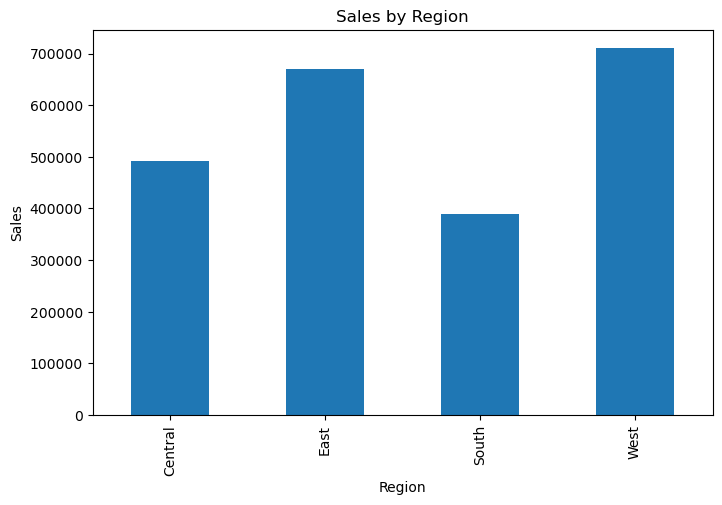

In [20]:
region_sales.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Sales by Region")
plt.ylabel("Sales")
plt.show()

In [21]:
category_sales = df.groupby(
    'Category'
)['Sales'].sum()

print(category_sales)

Category
Furniture          728658.5757
Office Supplies    705422.3340
Technology         827455.8730
Name: Sales, dtype: float64


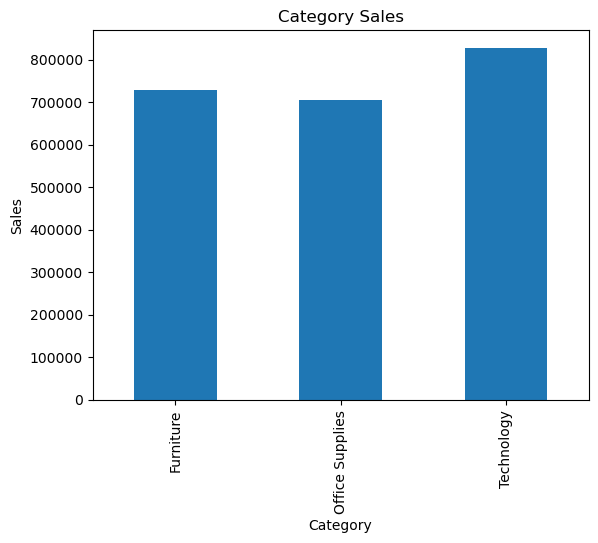

In [22]:
category_sales.plot(kind='bar')

plt.title("Category Sales")
plt.ylabel("Sales")
plt.show()

In [23]:
top_products = df.groupby(
    'Product_Name'
)['Sales'].sum().sort_values(
    ascending=False
).head(10)

print(top_products)

Product_Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24 Color                       18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64


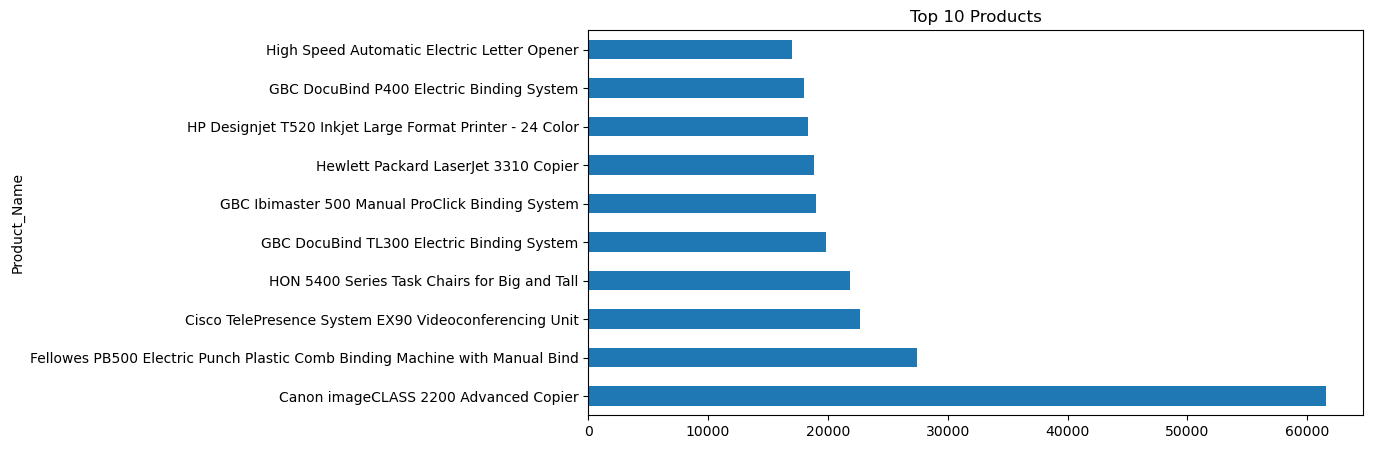

In [24]:
top_products.plot(
    kind='barh',
    figsize=(10,5)
)

plt.title("Top 10 Products")
plt.show()

In [25]:
worst_products = df.groupby(
    'Product_Name'
)['Sales'].sum().sort_values(
    ascending=True
).head(10)

print(worst_products)

Product_Name
Eureka Disposable Bags for Sanitaire Vibra Groomer I Upright Vac    1.624
Avery 5                                                             5.760
Xerox 20                                                            6.480
Grip Seal Envelopes                                                 7.072
Acme Serrated Blade Letter Opener                                   7.632
Avery Hi-Liter Pen Style Six-Color Fluorescent Set                  7.700
Avery Hi-Liter Comfort Grip Fluorescent Highlighter, Yellow Ink     7.800
Xerox 1989                                                          7.968
4009 Highlighters                                                   8.040
Stockwell Gold Paper Clips                                          8.096
Name: Sales, dtype: float64


In [26]:
monthly_sales = df.groupby(
    df['Order_Date'].dt.month
)['Sales'].sum()

monthly_sales

Order_Date
1      94291.6296
2      59371.1154
3     197573.5872
4     136283.0006
5     154086.7237
6     145837.5233
7     145535.6890
8     157315.9270
9     300103.4117
10    199496.2947
11    350161.7110
12    321480.1695
Name: Sales, dtype: float64

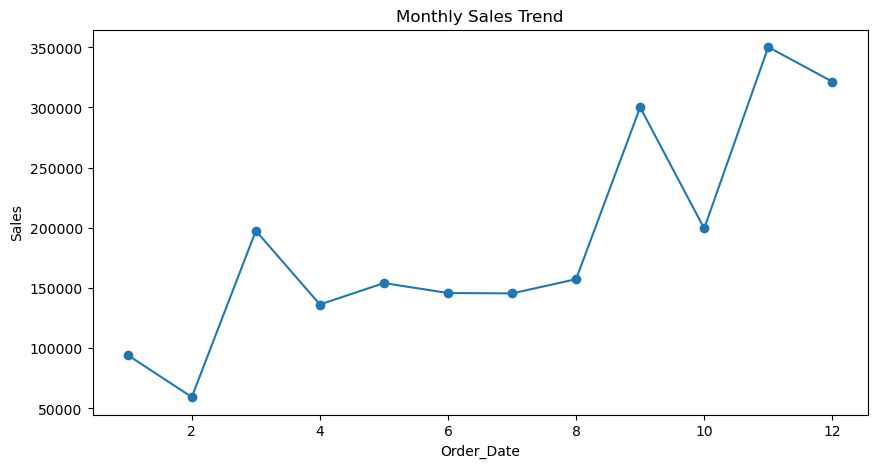

In [27]:
monthly_sales.plot(
    kind='line',
    marker='o',
    figsize=(10,5)
)

plt.title("Monthly Sales Trend")
plt.ylabel("Sales")

plt.show()

In [28]:
df.to_csv("cleaned_superstore.csv", index=False)

In [29]:
plt.savefig("chart_name.png", bbox_inches="tight")

<Figure size 640x480 with 0 Axes>